In [56]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import Point
import contextily as cx
from pathlib import Path
from pyproj import Transformer
from shapely.geometry import Point, LineString
import os
from pathlib import Path
from matplotlib.ticker import ScalarFormatter
from matplotlib.ticker import FormatStrFormatter
import matplotlib.patheffects as pe
from mpl_toolkits.axes_grid1 import make_axes_locatable


In [2]:
gravity_path = "../../data/gravity/raw_data/gps_data/gravity_05_27_2026.csv"
poi_path = "../../data/GPR/raw_data/GPS_Emlid/group2_onyx_mine.csv"

gravity_df = pd.read_csv(gravity_path)
poi_df = pd.read_csv(poi_path)

gravity_gps = gravity_df[["Name", "Longitude", "Latitude", "Ellipsoidal height"]].copy()
gravity_gps = gravity_gps.rename(columns={
    "Name": "station",
    "Ellipsoidal height": "elevation_m"
})

poi_gps = poi_df[["Name", "Longitude", "Latitude", "Elevation", "Ellipsoidal height"]].copy()
poi_gps = poi_gps.rename(columns={
    "Name": "point_name",
    "Elevation": "elevation_m",
    "Ellipsoidal height": "ellipsoidal_height_m"
})

gravity_gdf = gpd.GeoDataFrame(
    gravity_gps,
    geometry=gpd.points_from_xy(gravity_gps["Longitude"], gravity_gps["Latitude"]),
    crs="EPSG:4326"
)

poi_gdf = gpd.GeoDataFrame(
    poi_gps,
    geometry=gpd.points_from_xy(poi_gps["Longitude"], poi_gps["Latitude"]),
    crs="EPSG:4326"
)

In [3]:
gpr_folder_gopher = Path("../../data/GPR/raw_data/Gopher/")
gpr_folder_moose = Path("../../data/GPR/raw_data/Moose/")

gps_extensions = [".csv", ".txt", ".gps", ".gpx", ".kml", ".cor", ".xyz"]

gpr_gps_candidates = []

for folder in [gpr_folder_gopher, gpr_folder_moose]:
    for file in folder.rglob("*"):
        if file.is_file() and file.suffix.lower() in gps_extensions:
            gpr_gps_candidates.append(file)

print("Possible GPR GPS files found:", len(gpr_gps_candidates))
for file in gpr_gps_candidates:
    print(file)

Possible GPR GPS files found: 12
..\..\data\GPR\raw_data\Gopher\GPR_group2_2026_05_25_gopher_2026-05-25_0001.cor
..\..\data\GPR\raw_data\Gopher\GPR_group2_2026_05_25_gopher_2026-05-25_0002.cor
..\..\data\GPR\raw_data\Gopher\GPR_group2_2026_05_25_gopher_2026-05-25_0003.cor
..\..\data\GPR\raw_data\Gopher\GPR_group2_2026_05_25_gopher_2026-05-25_0004.cor
..\..\data\GPR\raw_data\Moose\GPR_group2_2026_05_21_2026-05-25_0001.cor
..\..\data\GPR\raw_data\Moose\GPR_group2_2026_05_21_2026-05-25_0002.cor
..\..\data\GPR\raw_data\Moose\GPR_group2_2026_05_21_2026-05-25_0003.cor
..\..\data\GPR\raw_data\Moose\GPR_group2_2026_05_21_2026-05-25_0004.cor
..\..\data\GPR\raw_data\Moose\GPR_group2_2026_05_21_2026-05-25_0005.cor
..\..\data\GPR\raw_data\Moose\GPR_group2_2026_05_21_2026-05-25_0006.cor
..\..\data\GPR\raw_data\Moose\GPR_group2_2026_05_21_2026-05-25_0007.cor
..\..\data\GPR\raw_data\Moose\GPR_group2_2026_05_21_2026-05-25_0008.cor


In [4]:
from shapely.geometry import LineString

gpr_dfs = []

for file in gpr_gps_candidates:
    temp = pd.read_csv(
        file,
        sep="\t",
        header=None,
        names=[
            "trace",
            "date",
            "time",
            "latitude",
            "lat_dir",
            "longitude",
            "lon_dir",
            "elevation_m",
            "elevation_unit",
            "quality"
        ]
    )
    
    temp["source_file"] = file.name
    
    if "gopher" in str(file).lower():
        temp["gpr_device"] = "Gopher"
    else:
        temp["gpr_device"] = "Moose"
    
    temp["line_name"] = file.stem
    gpr_dfs.append(temp)

gpr_df = pd.concat(gpr_dfs, ignore_index=True)

gpr_df["latitude"] = pd.to_numeric(gpr_df["latitude"], errors="coerce")
gpr_df["longitude"] = pd.to_numeric(gpr_df["longitude"], errors="coerce")
gpr_df["elevation_m"] = pd.to_numeric(gpr_df["elevation_m"], errors="coerce")

gpr_df.loc[gpr_df["lat_dir"].str.upper() == "S", "latitude"] *= -1
gpr_df.loc[gpr_df["lon_dir"].str.upper() == "W", "longitude"] *= -1

gpr_df = gpr_df.dropna(subset=["latitude", "longitude"]).copy()

gpr_points_gdf = gpd.GeoDataFrame(
    gpr_df,
    geometry=gpd.points_from_xy(gpr_df["longitude"], gpr_df["latitude"]),
    crs="EPSG:4326"
)

gpr_lines = []

for line_name, group in gpr_points_gdf.groupby("line_name"):
    group = group.sort_values("trace")
    
    if len(group) >= 2:
        gpr_lines.append({
            "line_name": line_name,
            "gpr_device": group["gpr_device"].iloc[0],
            "n_points": len(group),
            "geometry": LineString(group.geometry.tolist())
        })

gpr_lines_gdf = gpd.GeoDataFrame(gpr_lines, crs="EPSG:4326")

display(gpr_lines_gdf[["line_name", "gpr_device", "n_points"]])

C:\Users\molly\AppData\Local\Temp\ipykernel_17532\1900809686.py:34: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  gpr_df = pd.concat(gpr_dfs, ignore_index=True)


,line_name,gpr_device,n_points
0,GPR_group2_2026_05_21_2026-05-25_0001,Moose,8
1,GPR_group2_2026_05_21_2026-05-25_0002,Moose,162
2,GPR_group2_2026_05_21_2026-05-25_0003,Moose,138
3,GPR_group2_2026_05_21_2026-05-25_0004,Moose,460
4,GPR_group2_2026_05_21_2026-05-25_0005,Moose,466
5,GPR_group2_2026_05_21_2026-05-25_0007,Moose,121
6,GPR_group2_2026_05_21_2026-05-25_0008,Moose,98
7,GPR_group2_2026_05_25_gopher_2026-05-25_0001,Gopher,5
8,GPR_group2_2026_05_25_gopher_2026-05-25_0002,Gopher,2
9,GPR_group2_2026_05_25_gopher_2026-05-25_0003,Gopher,113


In [5]:
gravity_3857 = gravity_gdf.to_crs(epsg=3857)
poi_3857 = poi_gdf.to_crs(epsg=3857)
gpr_lines_3857 = gpr_lines_gdf.to_crs(epsg=3857)
gpr_points_3857 = gpr_points_gdf.to_crs(epsg=3857)

In [6]:
selected_gpr_lines = gpr_lines_3857[
    (
        (gpr_lines_3857["gpr_device"] == "Gopher") &
        (gpr_lines_3857["line_name"].str.endswith(("0003", "0004")))
    )
    |
    (
        (gpr_lines_3857["gpr_device"] == "Moose") &
        (gpr_lines_3857["line_name"].str.endswith(("0007", "0008")))
    )
].copy()

display(selected_gpr_lines[["line_name", "gpr_device", "n_points"]])

,line_name,gpr_device,n_points
5,GPR_group2_2026_05_21_2026-05-25_0007,Moose,121
6,GPR_group2_2026_05_21_2026-05-25_0008,Moose,98
9,GPR_group2_2026_05_25_gopher_2026-05-25_0003,Gopher,113
10,GPR_group2_2026_05_25_gopher_2026-05-25_0004,Gopher,65


In [7]:
anomaly_df = pd.DataFrame({
    "anomaly_id": [
        "G03-A", "G03-B", "G03-C",
        "G04-A", "G04-B",
        "M07-A",
        "M08-A", "M08-B"
    ],

    "line": [
        "Gopher 03", "Gopher 03", "Gopher 03",
        "Gopher 04", "Gopher 04",
        "Moose 07",
        "Moose 08", "Moose 08"
    ],

    "frequency_MHz": [
        600, 600, 600,
        600, 600,
        300,
        300, 300
    ],

    "easting": [
        344405.8, 344414.1, 344421.0,
        344417.2, 344414.2,
        344422.0,
        344404.5, 344414.0
    ],

    "northing": [
        4482540.1, 4482521.8, 4482499.8,
        4482507.0, 4482520.6,
        4482496.4,
        4482538.4, 4482517.1
    ],

    "twt_ns": [
        28.8, 15.8, 14.6,
        36.4, 23.9,
        128.3,
        40.8, 22.8
    ]
})

In [8]:
velocity = 0.10  # m/ns

anomaly_df["depth_m"] = (
    anomaly_df["twt_ns"] * velocity / 2
)

In [9]:
anomaly_gdf = gpd.GeoDataFrame(
    anomaly_df,
    geometry=gpd.points_from_xy(anomaly_df["easting"], anomaly_df["northing"]),
    crs="EPSG:32613"
)

anomaly_3857 = anomaly_gdf.to_crs(epsg=3857)

anomaly_3857[["anomaly_id", "line", "frequency_MHz", "twt_ns", "depth_m", "geometry"]]

,anomaly_id,line,frequency_MHz,twt_ns,depth_m,geometry
0,G03-A,Gopher 03,600,28.8,1.440,POINT (-11892889.795 4935792.762)
1,G03-B,Gopher 03,600,15.8,0.790,POINT (-11892878.4 4935768.874)
2,G03-C,Gopher 03,600,14.6,0.730,POINT (-11892868.742 4935740.072)
3,G04-A,Gopher 04,600,36.4,1.820,POINT (-11892873.927 4935749.456)
4,G04-B,Gopher 04,600,23.9,1.195,POINT (-11892878.236 4935767.296)
5,M07-A,Moose 07,300,128.3,6.415,POINT (-11892867.337 4935735.619)
6,M08-A,Moose 08,300,40.8,2.040,POINT (-11892891.455 4935790.487)
7,M08-B,Moose 08,300,22.8,1.140,POINT (-11892878.403 4935762.678)


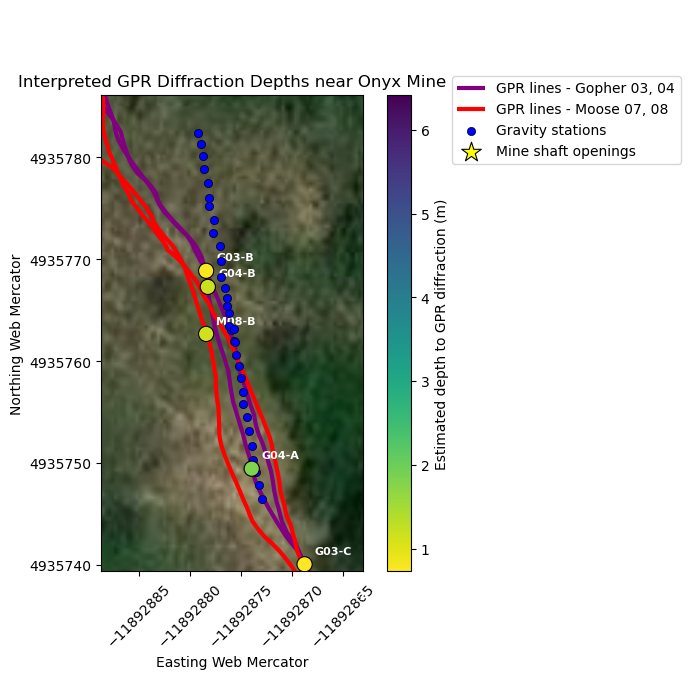

In [10]:
all_layers = pd.concat([
    gravity_3857[["geometry"]],
    poi_3857[["geometry"]],
    selected_gpr_lines[["geometry"]],
    anomaly_3857[["geometry"]]
])

xmin, ymin, xmax, ymax = all_layers.total_bounds
buffer = -5

fig, ax = plt.subplots(figsize=(9, 7))

ax.set_xlim(xmin - buffer, xmax + buffer)
ax.set_ylim(ymin - 1.9*buffer, ymax + 3.9*buffer)

cx.add_basemap(
    ax,
    source=cx.providers.Esri.WorldImagery,
    zoom=19,
    attribution=False
)

selected_gpr_lines[selected_gpr_lines["gpr_device"] == "Gopher"].plot(
    ax=ax,
    linewidth=3,
    color="purple",
    label="GPR lines - Gopher 03, 04",
    zorder=2
)

selected_gpr_lines[selected_gpr_lines["gpr_device"] == "Moose"].plot(
    ax=ax,
    linewidth=3,
    color="red",
    label="GPR lines - Moose 07, 08",
    zorder=2
)

gravity_3857.plot(
    ax=ax,
    marker="o",
    markersize=35,
    color="blue",
    edgecolor="black",
    linewidth=0.5,
    label="Gravity stations",
    zorder=4
)

poi_3857.plot(
    ax=ax,
    marker="*",
    markersize=220,
    color="yellow",
    edgecolor="black",
    linewidth=0.8,
    label="Mine shaft openings",
    zorder=5
)

anomaly_3857.plot(
    ax=ax,
    column="depth_m",
    cmap="viridis_r",
    markersize=120,
    edgecolor="black",
    linewidth=0.8,
    legend=True,
    legend_kwds={"label": "Estimated depth to GPR diffraction (m)"},
    zorder=6
)

for idx, row in anomaly_3857.iterrows():
    ax.text(
        row.geometry.x + 1,
        row.geometry.y + 1,
        row["anomaly_id"],
        fontsize=8,
        weight="bold",
        color="white",
        path_effects=[]
    )

ax.set_title("Interpreted GPR Diffraction Depths near Onyx Mine")
ax.set_xlabel("Easting Web Mercator")
ax.set_ylabel("Northing Web Mercator")
ax.legend(
    loc="upper left",
    bbox_to_anchor=(1.34, 1.04),
    ncol=1,
    borderaxespad=0
)

ax.ticklabel_format(style="plain", axis="both", useOffset=False)
ax.xaxis.set_major_formatter(ScalarFormatter(useOffset=False))
ax.yaxis.set_major_formatter(ScalarFormatter(useOffset=False))
ax.get_xaxis().get_major_formatter().set_scientific(False)
ax.get_yaxis().get_major_formatter().set_scientific(False)

plt.xticks(rotation=45)
plt.tight_layout(rect=[0, 0, 0.78, 1])
plt.show()

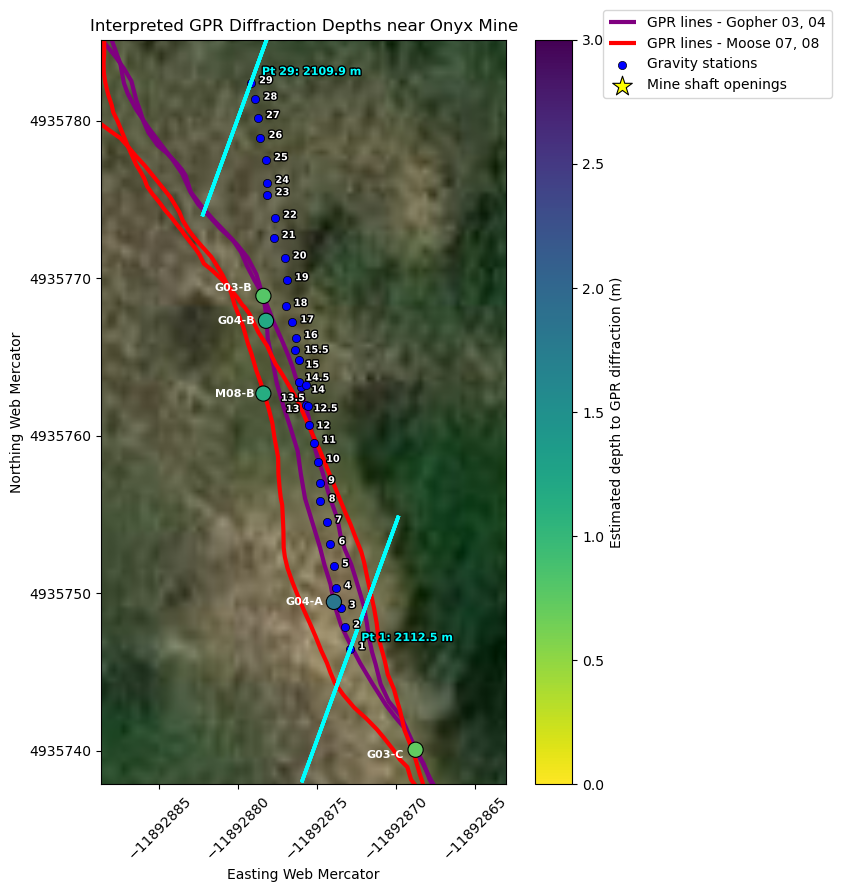

In [19]:
all_layers = pd.concat([
    gravity_3857[["geometry"]],
    poi_3857[["geometry"]],
    selected_gpr_lines[["geometry"]],
    anomaly_3857[["geometry"]]
])

xmin, ymin, xmax, ymax = all_layers.total_bounds
buffer = -5

fig, ax = plt.subplots(figsize=(9, 9))

ax.set_xlim(xmin - buffer, xmax + buffer)
ax.set_ylim(ymin - 1.6*buffer, ymax + 4.1*buffer)

cx.add_basemap(
    ax,
    source=cx.providers.Esri.WorldImagery,
    zoom=19,
    attribution=False
)

selected_gpr_lines[selected_gpr_lines["gpr_device"] == "Gopher"].plot(
    ax=ax,
    linewidth=3,
    color="purple",
    label="GPR lines - Gopher 03, 04",
    zorder=2
)

selected_gpr_lines[selected_gpr_lines["gpr_device"] == "Moose"].plot(
    ax=ax,
    linewidth=3,
    color="red",
    label="GPR lines - Moose 07, 08",
    zorder=2
)

gravity_3857.plot(
    ax=ax,
    marker="o",
    markersize=35,
    color="blue",
    edgecolor="black",
    linewidth=0.5,
    label="Gravity stations",
    zorder=4
)

# ----------------------------
# Label every gravity station with manual offsets
# ----------------------------

import matplotlib.patheffects as pe

# Find the gravity station label column
if "station_num" in gravity_3857.columns:
    gravity_label_col = "station_num"
elif "station" in gravity_3857.columns:
    gravity_label_col = "station"
elif "Name" in gravity_3857.columns:
    gravity_label_col = "Name"
else:
    raise ValueError("Could not find gravity station label column. Check gravity_3857.columns")

# ----------------------------
# Manual gravity label offsets
# ----------------------------
# Format:
# station_number: (x_offset, y_offset, ha, va)
#
# x_offset:
#   positive = right
#   negative = left
#
# y_offset:
#   positive = up
#   negative = down

gravity_label_offsets = {
    15:   (5, -3, "left", "center"),
    15.5: (7, 0,  "left", "center"),
    16:   (6, 2,  "left", "center"),
    14.5: (22, 3,  "right", "center"),
    14:   (17, -2,  "right", "center"),
    13.5: (-18, -9,   "left", "center"),
    13:   (-5, -3, "right", "center"),
    12.5: (4, -2,  "left", "center"),
    12:   (15, 0, "right", "center"),
}

# Default position for all other gravity labels
default_gravity_label_offset = (6, 2, "left", "center")

for idx, row in gravity_3857.iterrows():

    label = row[gravity_label_col]

    # Convert label to a clean number if possible
    try:
        label_num = float(label)

        if label_num.is_integer():
            display_label = str(int(label_num))
            lookup_label = int(label_num)
        else:
            display_label = str(label_num).rstrip("0").rstrip(".")
            lookup_label = label_num

    except:
        display_label = str(label)
        lookup_label = label

    x_offset, y_offset, ha, va = gravity_label_offsets.get(
        lookup_label,
        default_gravity_label_offset
    )

    ax.annotate(
        display_label,
        xy=(row.geometry.x, row.geometry.y),
        xytext=(x_offset, y_offset),
        textcoords="offset points",
        fontsize=7,
        color="white",
        weight="bold",
        ha=ha,
        va=va,
        zorder=10,
        path_effects=[
            pe.withStroke(linewidth=2, foreground="black")
        ]
    )

    
poi_3857.plot(
    ax=ax,
    marker="*",
    markersize=220,
    color="yellow",
    edgecolor="black",
    linewidth=0.8,
    label="Mine shaft openings",
    zorder=5
)

# ----------------------------
# Set color scale for zoomed-in anomalies
# ----------------------------
zoom_vmin = 0.0
zoom_vmax = 3.0

anomaly_3857.plot(
    ax=ax,
    column="depth_m",
    cmap="viridis_r",
    vmin=zoom_vmin,
    vmax=zoom_vmax,
    markersize=120,
    edgecolor="black",
    linewidth=0.8,
    legend=True,
    legend_kwds={
        "label": "Estimated depth to GPR diffraction (m)"
    },
    zorder=6
)

# ----------------------------
# Adjustable label positions
# ----------------------------
label_offsets = {
    "G03-A": (10, 0, "left", "center"),
    "G03-B": (10, 6, "left", "center"),
    "G03-C": (10, -4, "left", "center"),

    "G04-A": (10, 0, "left", "center"),
    "G04-B": (10, 0, "left", "center"),

    "M07-B": (10, 0, "left", "center"),
    "M08-B": (10, 0, "left", "center"),
}

default_label_offset = (10, 0, "left", "center")

for idx, row in anomaly_3857.iterrows():

    anomaly_id = row["anomaly_id"]

    x_offset, y_offset, ha, va = label_offsets.get(
        anomaly_id,
        default_label_offset
    )

    ax.annotate(
        anomaly_id,
        xy=(row.geometry.x, row.geometry.y),
        xytext=(x_offset-45, y_offset),
        textcoords="offset points",
        fontsize=8,
        weight="bold",
        color="white",
        ha=ha,
        va=va,
        zorder=10
    )

ax.set_title("Interpreted GPR Diffraction Depths near Onyx Mine")
ax.set_xlabel("Easting Web Mercator")
ax.set_ylabel("Northing Web Mercator")

ax.legend(
    loc="upper left",
    bbox_to_anchor=(1.24, 1.04),
    ncol=1,
    borderaxespad=0
)

# ----------------------------
# Add manual elevation/topo lines at gravity stations 1 and 29
# ----------------------------

# Find station column
if "station_num" in gravity_3857.columns:
    gravity_station_col = "station_num"
elif "station" in gravity_3857.columns:
    gravity_station_col = "station"
elif "Name" in gravity_3857.columns:
    gravity_station_col = "Name"
else:
    raise ValueError("Could not find gravity station column. Check gravity_3857.columns")

# Find elevation column
possible_elevation_cols = [
    "elevation",
    "Elevation",
    "elev",
    "Elev",
    "elevation_m",
    "Elevation_m",
    "elevation_ft",
    "Elevation_ft",
    "altitude",
    "Altitude",
    "Z",
    "z"
]

elevation_col = None
for col in possible_elevation_cols:
    if col in gravity_3857.columns:
        elevation_col = col
        break

if elevation_col is None:
    raise ValueError("Could not find elevation column. Check gravity_3857.columns")

# Make sure station numbers are numeric
gravity_3857["station_num_clean"] = pd.to_numeric(
    gravity_3857[gravity_station_col],
    errors="coerce"
)

# Select gravity stations 1 and 29
topo_points = gravity_3857[
    gravity_3857["station_num_clean"].isin([1, 29])
].copy()



for idx, row in topo_points.iterrows():

    station = int(row["station_num_clean"])
    x0 = row.geometry.x
    y0 = row.geometry.y

    settings = topo_line_settings[station]

    length_m = settings["length_m"]
    angle_deg = settings["angle_deg"]

    angle_rad = np.deg2rad(angle_deg)

    dx = (length_m / 2) * np.cos(angle_rad)
    dy = (length_m / 2) * np.sin(angle_rad)

    line = LineString([
        (x0 - dx, y0 - dy),
        (x0 + dx, y0 + dy)
    ])

    topo_lines.append({
        "station": station,
        "elevation": row[elevation_col],
        "geometry": line
    })

topo_lines_gdf = gpd.GeoDataFrame(
    topo_lines,
    geometry="geometry",
    crs=gravity_3857.crs
)

# Plot manual topo/elevation lines
topo_lines_gdf.plot(
    ax=ax,
    color="cyan",
    linewidth=2.5,
    linestyle="-",
    zorder=7,
    label="Manual elevation lines"
)

# Label each manual topo/elevation line
for idx, row in topo_points.iterrows():

    station = int(row["station_num_clean"])
    elevation = row[elevation_col]

    x_offset, y_offset = topo_line_settings[station]["label_offset"]

    ax.annotate(
        f"Pt {station}: {elevation:.1f} m",
        xy=(row.geometry.x, row.geometry.y),
        xytext=(x_offset, y_offset),
        textcoords="offset points",
        fontsize=8,
        color="cyan",
        weight="bold",
        ha="left",
        va="center",
        zorder=11,
        path_effects=[
            pe.withStroke(linewidth=2, foreground="black")
        ]
    )


   # Label projected endpoint
for idx, row in mine_projection_endpoint.iterrows():
    ax.annotate(
        text="60 m",
        xy=(row.geometry.x, row.geometry.y),
        xytext=(6, 6),
        textcoords="offset points",
        fontsize=8,
        color="black",
        fontweight="bold",
        bbox=dict(facecolor="white", edgecolor="none", alpha=0.7, pad=1.5),
        zorder=8
    )
 
ax.ticklabel_format(style="plain", axis="both", useOffset=False)
ax.xaxis.set_major_formatter(ScalarFormatter(useOffset=False))
ax.yaxis.set_major_formatter(ScalarFormatter(useOffset=False))
ax.get_xaxis().get_major_formatter().set_scientific(False)
ax.get_yaxis().get_major_formatter().set_scientific(False)

plt.xticks(rotation=45)
plt.tight_layout(rect=[0, 0, 0.88, 1])
plt.show()

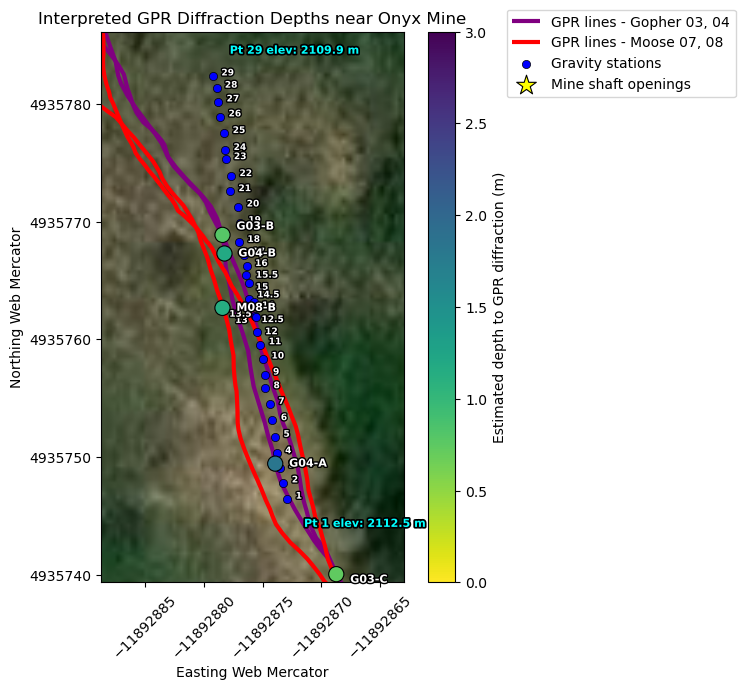

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from matplotlib.ticker import ScalarFormatter
import contextily as cx

# ============================================================
# MAP EXTENT
# ============================================================

all_layers = pd.concat([
    gravity_3857[["geometry"]],
    poi_3857[["geometry"]],
    selected_gpr_lines[["geometry"]],
    anomaly_3857[["geometry"]]
])

xmin, ymin, xmax, ymax = all_layers.total_bounds

# Negative buffer zooms in tighter.
# Positive buffer zooms out.
buffer = -5

# ============================================================
# CREATE FIGURE
# ============================================================

fig, ax = plt.subplots(figsize=(9, 7))

ax.set_xlim(xmin - buffer, xmax + buffer)
ax.set_ylim(ymin - 1.9 * buffer, ymax + 3.9 * buffer)

# ============================================================
# BASEMAP
# ============================================================

cx.add_basemap(
    ax,
    source=cx.providers.Esri.WorldImagery,
    zoom=19,
    attribution=False
)

# ============================================================
# GPR LINES
# ============================================================

selected_gpr_lines[selected_gpr_lines["gpr_device"] == "Gopher"].plot(
    ax=ax,
    linewidth=3,
    color="purple",
    label="GPR lines - Gopher 03, 04",
    zorder=2
)

selected_gpr_lines[selected_gpr_lines["gpr_device"] == "Moose"].plot(
    ax=ax,
    linewidth=3,
    color="red",
    label="GPR lines - Moose 07, 08",
    zorder=2
)

# ============================================================
# GRAVITY POINTS
# ============================================================

gravity_3857.plot(
    ax=ax,
    marker="o",
    markersize=35,
    color="blue",
    edgecolor="black",
    linewidth=0.5,
    label="Gravity stations",
    zorder=4
)

# ============================================================
# LABEL EVERY GRAVITY STATION
# ============================================================

# Find gravity label column
if "station_num" in gravity_3857.columns:
    gravity_label_col = "station_num"
elif "station" in gravity_3857.columns:
    gravity_label_col = "station"
elif "Name" in gravity_3857.columns:
    gravity_label_col = "Name"
else:
    raise ValueError("Could not find gravity station label column. Check gravity_3857.columns")

# Manual gravity label offsets
# Format:
# station_number: (x_offset, y_offset, horizontal_alignment, vertical_alignment)
#
# x_offset:
#   positive = right
#   negative = left
#
# y_offset:
#   positive = up
#   negative = down


gravity_label_offsets = {
    15:   (5, -3, "left", "center"),
    15.5: (7, 0,  "left", "center"),
    16:   (6, 2,  "left", "center"),
    14.5: (22, 3,  "right", "center"),
    14:   (17, -2,  "right", "center"),
    13.5: (-18, -9,   "left", "center"),
    13:   (-5, -3, "right", "center"),
    12.5: (4, -2,  "left", "center"),
    12:   (15, 0, "right", "center"),
}

default_gravity_label_offset = (6, 2, "left", "center")

for idx, row in gravity_3857.iterrows():

    label = row[gravity_label_col]

    try:
        label_num = float(label)

        if label_num.is_integer():
            display_label = str(int(label_num))
            lookup_label = int(label_num)
        else:
            display_label = str(label_num).rstrip("0").rstrip(".")
            lookup_label = label_num

    except:
        display_label = str(label)
        lookup_label = label

    x_offset, y_offset, ha, va = gravity_label_offsets.get(
        lookup_label,
        default_gravity_label_offset
    )

    ax.annotate(
        display_label,
        xy=(row.geometry.x, row.geometry.y),
        xytext=(x_offset, y_offset),
        textcoords="offset points",
        fontsize=6.5,
        color="white",
        weight="bold",
        ha=ha,
        va=va,
        zorder=10,
        path_effects=[
            pe.withStroke(linewidth=2, foreground="black")
        ]
    )

# ============================================================
# ELEVATION LABELS FOR GRAVITY POINTS 1 AND 29 ONLY
# ============================================================

# Find gravity station column
if "station_num" in gravity_3857.columns:
    gravity_station_col = "station_num"
elif "station" in gravity_3857.columns:
    gravity_station_col = "station"
elif "Name" in gravity_3857.columns:
    gravity_station_col = "Name"
else:
    raise ValueError("Could not find gravity station column. Check gravity_3857.columns")

# Find elevation column
possible_elevation_cols = [
    "elevation",
    "Elevation",
    "elev",
    "Elev",
    "elevation_m",
    "Elevation_m",
    "elevation_ft",
    "Elevation_ft",
    "altitude",
    "Altitude",
    "Z",
    "z"
]

elevation_col = None

for col in possible_elevation_cols:
    if col in gravity_3857.columns:
        elevation_col = col
        break

if elevation_col is None:
    raise ValueError("Could not find elevation column. Check gravity_3857.columns")

# Clean station numbers
gravity_3857["station_num_clean"] = pd.to_numeric(
    gravity_3857[gravity_station_col],
    errors="coerce"
)

# Select only gravity points 1 and 29
elevation_label_points = gravity_3857[
    gravity_3857["station_num_clean"].isin([1, 29])
].copy()

# Manual elevation label offsets
# Format:
# station: (x_offset, y_offset, horizontal_alignment, vertical_alignment)

elevation_label_offsets = {
    1:  (12, -18, "left", "center"),
    29: (12, 18, "left", "center")
}

default_elevation_label_offset = (12, 12, "left", "center")

for idx, row in elevation_label_points.iterrows():

    station = int(row["station_num_clean"])
    elevation = float(row[elevation_col])

    x_offset, y_offset, ha, va = elevation_label_offsets.get(
        station,
        default_elevation_label_offset
    )

    ax.annotate(
        f"Pt {station} elev: {elevation:.1f} m",
        xy=(row.geometry.x, row.geometry.y),
        xytext=(x_offset, y_offset),
        textcoords="offset points",
        fontsize=8,
        color="cyan",
        weight="bold",
        ha=ha,
        va=va,
        zorder=12,
        path_effects=[
            pe.withStroke(linewidth=2.5, foreground="black")
        ]
    )

# ============================================================
# MINE SHAFT OPENINGS
# ============================================================

poi_3857.plot(
    ax=ax,
    marker="*",
    markersize=220,
    color="yellow",
    edgecolor="black",
    linewidth=0.8,
    label="Mine shaft openings",
    zorder=5
)

# ============================================================
# GPR DIFFRACTION ANOMALIES
# ============================================================

zoom_vmin = 0.0
zoom_vmax = 3.0

anomaly_3857.plot(
    ax=ax,
    column="depth_m",
    cmap="viridis_r",
    vmin=zoom_vmin,
    vmax=zoom_vmax,
    markersize=120,
    edgecolor="black",
    linewidth=0.8,
    legend=True,
    legend_kwds={
        "label": "Estimated depth to GPR diffraction (m)",
        "ticks": [0, 0.5, 1, 1.5, 2, 2.5, 3]
    },
    zorder=6
)

# ============================================================
# GPR ANOMALY LABELS
# ============================================================

label_offsets = {
    "G03-A": (10, 0, "left", "center"),
    "G03-B": (10, 6, "left", "center"),
    "G03-C": (10, -4, "left", "center"),

    "G04-A": (10, 0, "left", "center"),
    "G04-B": (10, 0, "left", "center"),

    "M07-B": (10, 0, "left", "center"),
    "M08-B": (10, 0, "left", "center"),
}

default_label_offset = (10, 0, "left", "center")

for idx, row in anomaly_3857.iterrows():

    anomaly_id = row["anomaly_id"]

    x_offset, y_offset, ha, va = label_offsets.get(
        anomaly_id,
        default_label_offset
    )

    ax.annotate(
        anomaly_id,
        xy=(row.geometry.x, row.geometry.y),
        xytext=(x_offset, y_offset),
        textcoords="offset points",
        fontsize=8,
        weight="bold",
        color="white",
        ha=ha,
        va=va,
        zorder=10,
        path_effects=[
            pe.withStroke(linewidth=2, foreground="black")
        ]
    )

# ============================================================
# FINAL FORMATTING
# ============================================================

ax.set_title("Interpreted GPR Diffraction Depths near Onyx Mine")
ax.set_xlabel("Easting Web Mercator")
ax.set_ylabel("Northing Web Mercator")

ax.legend(
    loc="upper left",
    bbox_to_anchor=(1.34, 1.04),
    ncol=1,
    borderaxespad=0
)

ax.ticklabel_format(style="plain", axis="both", useOffset=False)
ax.xaxis.set_major_formatter(ScalarFormatter(useOffset=False))
ax.yaxis.set_major_formatter(ScalarFormatter(useOffset=False))
ax.get_xaxis().get_major_formatter().set_scientific(False)
ax.get_yaxis().get_major_formatter().set_scientific(False)

plt.xticks(rotation=45)
plt.tight_layout(rect=[0, 0, 0.78, 1])
plt.show()

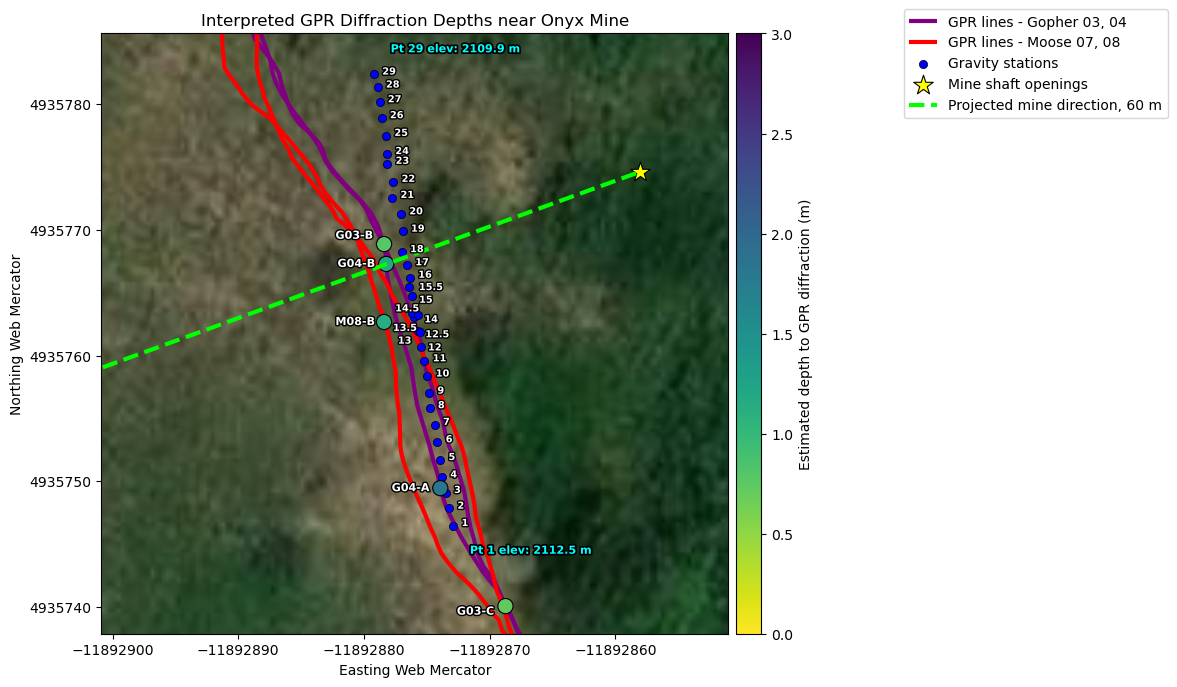

In [55]:
figsize = (10, 20)
buffer = -5

zoom_vmin = 0.0
zoom_vmax = 3.0

mine_start_name = "above big entrance to mine"
mine_projection_length_m = 60
mine_projection_azimuth_deg = 250

gravity_marker_size = 35
poi_marker_size = 220
anomaly_marker_size = 120

gravity_label_size = 7
anomaly_label_size = 8
elevation_label_size = 8

gravity_label_offsets = {
    15:   (5, -3, "left", "center"),
    15.5: (7, 0, "left", "center"),
    16:   (6, 2, "left", "center"),
    14.5: (5, 3, "right", "center"),
    14:   (17, -2, "right", "center"),
    13.5: (-18, -9, "left", "center"),
    13:   (-5, -7, "right", "center"),
    12.5: (4, -2, "left", "center"),
    12:   (15, 0, "right", "center"),
}

default_gravity_label_offset = (6, 2, "left", "center")

elevation_label_offsets = {
    1:  (12, -18, "left", "center"),
    29: (12, 18, "left", "center"),
}

anomaly_label_offsets = {
    "G03-A": (10, 0, "left", "center"),
    "G03-B": (10, 6, "left", "center"),
    "G03-C": (10, -4, "left", "center"),
    "G04-A": (10, 0, "left", "center"),
    "G04-B": (10, 0, "left", "center"),
    "M07-B": (10, 0, "left", "center"),
    "M08-B": (10, 0, "left", "center"),
}

default_anomaly_label_offset = (10, 0, "left", "center")


# ============================================================
# Helper functions
# ============================================================

def find_col(gdf, possible_cols, error_message):
    for col in possible_cols:
        if col in gdf.columns:
            return col
    raise ValueError(error_message)


def clean_label(value):
    try:
        value = float(value)

        if value.is_integer():
            return str(int(value)), int(value)

        return str(value).rstrip("0").rstrip("."), value

    except Exception:
        return str(value), value


# ============================================================
# Find needed columns
# ============================================================

gravity_station_col = find_col(
    gravity_3857,
    ["station_num", "station", "Name"],
    "Could not find gravity station column. Check gravity_3857.columns."
)

elevation_col = find_col(
    gravity_3857,
    [
        "elevation_m", "Elevation_m",
        "elevation", "Elevation",
        "elev", "Elev",
        "elevation_ft", "Elevation_ft",
        "altitude", "Altitude",
        "Z", "z"
    ],
    "Could not find elevation column. Check gravity_3857.columns."
)

poi_name_col = find_col(
    poi_3857,
    ["point_name", "Name", "name"],
    "Could not find POI name column. Check poi_3857.columns."
)


# ============================================================
# Prep gravity station numbers
# ============================================================

gravity_3857 = gravity_3857.copy()

gravity_3857["station_num_clean"] = pd.to_numeric(
    gravity_3857[gravity_station_col],
    errors="coerce"
)


# ============================================================
# Build projected mine line
# ============================================================

mine_start = poi_3857[
    poi_3857[poi_name_col]
    .astype(str)
    .str.lower()
    .str.contains(mine_start_name.lower(), na=False)
].copy()

if mine_start.empty:
    raise ValueError(
        f"Could not find POI containing '{mine_start_name}'. "
        f"Available POI names are:\n{poi_3857[poi_name_col].tolist()}"
    )

mine_start_point = mine_start.geometry.iloc[0]

azimuth_rad = np.deg2rad(mine_projection_azimuth_deg)

dx = mine_projection_length_m * np.sin(azimuth_rad)
dy = mine_projection_length_m * np.cos(azimuth_rad)

mine_end_point = Point(
    mine_start_point.x + dx,
    mine_start_point.y + dy
)

mine_projection_line = gpd.GeoDataFrame(
    {
        "label": ["Projected mine direction"],
        "geometry": [LineString([mine_start_point, mine_end_point])]
    },
    crs=poi_3857.crs
)

mine_projection_endpoint = gpd.GeoDataFrame(
    {
        "label": [f"{mine_projection_length_m} m"],
        "geometry": [mine_end_point]
    },
    crs=poi_3857.crs
)


# ============================================================
# Set map extent
# ============================================================

all_layers = pd.concat([
    gravity_3857[["geometry"]],
    poi_3857[["geometry"]],
    selected_gpr_lines[["geometry"]],
    anomaly_3857[["geometry"]],
    mine_projection_line[["geometry"]],
    mine_projection_endpoint[["geometry"]],
])

xmin, ymin, xmax, ymax = all_layers.total_bounds


# ============================================================
# Create figure
# ============================================================

fig, ax = plt.subplots(figsize=figsize)

ax.set_xlim(xmin - 2.7*buffer, xmax + -1.4*buffer)
ax.set_ylim(ymin - 1.6 * buffer, ymax + 4 * buffer)


# ============================================================
# Basemap
# ============================================================

cx.add_basemap(
    ax,
    source=cx.providers.Esri.WorldImagery,
    zoom=19,
    attribution=False
)


# ============================================================
# Plot GPR lines
# ============================================================

selected_gpr_lines[selected_gpr_lines["gpr_device"] == "Gopher"].plot(
    ax=ax,
    linewidth=3,
    color="purple",
    label="GPR lines - Gopher 03, 04",
    zorder=2
)

selected_gpr_lines[selected_gpr_lines["gpr_device"] == "Moose"].plot(
    ax=ax,
    linewidth=3,
    color="red",
    label="GPR lines - Moose 07, 08",
    zorder=2
)


# ============================================================
# Plot gravity stations
# ============================================================

gravity_3857.plot(
    ax=ax,
    marker="o",
    markersize=gravity_marker_size,
    color="blue",
    edgecolor="black",
    linewidth=0.5,
    label="Gravity stations",
    zorder=4
)


# ============================================================
# Plot mine shaft openings
# ============================================================

poi_3857.plot(
    ax=ax,
    marker="*",
    markersize=poi_marker_size,
    color="yellow",
    edgecolor="black",
    linewidth=0.8,
    label="Mine shaft openings",
    zorder=5
)


# ============================================================
# Plot projected mine line
# ============================================================

mine_projection_line.plot(
    ax=ax,
    color="lime",
    linewidth=3,
    linestyle="--",
    label="Projected mine direction, 60 m",
    zorder=8
)

mine_projection_endpoint.plot(
    ax=ax,
    marker="x",
    markersize=90,
    color="lime",
    linewidth=2,
    zorder=9
)

for _, row in mine_projection_endpoint.iterrows():
    ax.annotate(
        text=f"{mine_projection_length_m} m",
        xy=(row.geometry.x, row.geometry.y),
        xytext=(6, 6),
        textcoords="offset points",
        fontsize=8,
        color="black",
        fontweight="bold",
        bbox=dict(
            facecolor="white",
            edgecolor="none",
            alpha=0.75,
            pad=1.5
        ),
        zorder=10
    )


# ============================================================
# Plot GPR diffraction anomalies with fixed colorbar
# ============================================================

divider = make_axes_locatable(ax)

cax = divider.append_axes(
    "right",
    size="4%",
    pad=0.08
)

anomaly_3857.plot(
    ax=ax,
    column="depth_m",
    cmap="viridis_r",
    vmin=zoom_vmin,
    vmax=zoom_vmax,
    markersize=anomaly_marker_size,
    edgecolor="black",
    linewidth=0.8,
    legend=True,
    cax=cax,
    legend_kwds={
        "label": "Estimated depth to GPR diffraction (m)",
        "ticks": [0, 0.5, 1, 1.5, 2, 2.5, 3]
    },
    zorder=6
)


# ============================================================
# Label gravity stations
# ============================================================

for _, row in gravity_3857.iterrows():
    display_label, lookup_label = clean_label(row[gravity_station_col])

    x_offset, y_offset, ha, va = gravity_label_offsets.get(
        lookup_label,
        default_gravity_label_offset
    )

    ax.annotate(
        display_label,
        xy=(row.geometry.x, row.geometry.y),
        xytext=(x_offset, y_offset),
        textcoords="offset points",
        fontsize=gravity_label_size,
        color="white",
        weight="bold",
        ha=ha,
        va=va,
        zorder=10,
        path_effects=[
            pe.withStroke(linewidth=2, foreground="black")
        ]
    )


# ============================================================
# Label elevations at gravity points 1 and 29 only
# ============================================================

elevation_points = gravity_3857[
    gravity_3857["station_num_clean"].isin([1, 29])
].copy()

for _, row in elevation_points.iterrows():
    station = int(row["station_num_clean"])
    elevation = float(row[elevation_col])

    x_offset, y_offset, ha, va = elevation_label_offsets.get(
        station,
        (12, 12, "left", "center")
    )

    ax.annotate(
        f"Pt {station} elev: {elevation:.1f} m",
        xy=(row.geometry.x, row.geometry.y),
        xytext=(x_offset, y_offset),
        textcoords="offset points",
        fontsize=elevation_label_size,
        color="cyan",
        weight="bold",
        ha=ha,
        va=va,
        zorder=12,
        path_effects=[
            pe.withStroke(linewidth=2.5, foreground="black")
        ]
    )


# ============================================================
# Label GPR anomalies
# ============================================================

for _, row in anomaly_3857.iterrows():
    anomaly_id = row["anomaly_id"]

    x_offset, y_offset, ha, va = anomaly_label_offsets.get(
        anomaly_id,
        default_anomaly_label_offset
    )

    ax.annotate(
        anomaly_id,
        xy=(row.geometry.x, row.geometry.y),
        xytext=(x_offset - 45, y_offset),
        textcoords="offset points",
        fontsize=anomaly_label_size,
        weight="bold",
        color="white",
        ha=ha,
        va=va,
        zorder=10,
        path_effects=[
            pe.withStroke(linewidth=2, foreground="black")
        ]
    )


# ============================================================
# Final formatting
# ============================================================

ax.set_title("Interpreted GPR Diffraction Depths near Onyx Mine")
ax.set_xlabel("Easting Web Mercator")
ax.set_ylabel("Northing Web Mercator")

ax.legend(
    loc="upper left",
    bbox_to_anchor=(1.28, 1.04),
    ncol=1,
    borderaxespad=0
)

ax.ticklabel_format(style="plain", axis="both", useOffset=False)
ax.xaxis.set_major_formatter(ScalarFormatter(useOffset=False))
ax.yaxis.set_major_formatter(ScalarFormatter(useOffset=False))
ax.get_xaxis().get_major_formatter().set_scientific(False)
ax.get_yaxis().get_major_formatter().set_scientific(False)

plt.xticks(rotation=45)

plt.subplots_adjust(
    left=0.1,
    right=0.76,
    bottom=0.12,
    top=0.92
)

plt.show()